In [1]:
# Task 2 - Exploratory Data Analysis
# Dataset: IMDB Top 250 Movies

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
df = pd.read_csv("../Task1_WebScraping/imdb_top250.csv")

print("data loaded successfully")
print(f"shape:{df.shape}")
print(f"\ncolumns:{df.columns.tolist()}")
print(f"\nfirst 5 rows:")
df.head()

data loaded successfully
shape:(250, 9)

columns:['Rank', 'Title', 'Year', 'Rating', 'Votes', 'Genre', 'Director', 'Description', 'Content_Rating']

first 5 rows:


,Rank,Title,Year,Rating,Votes,Genre,Director,Description,Content_Rating
0,1,Yôjinbô,1961,8.2,123512,"Action, Drama, Thriller",Akira Kurosawa,A crafty ronin comes to a town divided by two ...,Not Rated
1,2,Witness for the Prosecution,1958,8.4,125962,"Crime, Drama, Mystery",Billy Wilder,A veteran British barrister must defend his cl...,Approved
2,3,Whiplash,2014,8.5,853539,"Drama, Music",Damien Chazelle,A promising young drummer enrolls at a cut-thr...,R
3,4,Warrior,2011,8.2,472768,"Action, Drama, Sport",Gavin O&apos;Connor,The youngest son of an alcoholic former boxer ...,PG-13
4,5,WALL·E,2008,8.4,1112059,"Animation, Adventure, Family",Andrew Stanton,"In the distant future, a small waste-collectin...",G


In [3]:
# BAsic overview of the dataset
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)

print(f"\n📊 Total Movies: {len(df)}")
print(f"📋 Total Columns: {len(df.columns)}")

print("\n🔍 Data Types:")
print(df.dtypes)

print("\n❓ Missing Values:")
print(df.isnull().sum())

print("\n📈 Numerical Columns Stats:")
df.describe()

DATASET OVERVIEW

📊 Total Movies: 250
📋 Total Columns: 9

🔍 Data Types:
Rank                int64
Title                 str
Year                int64
Rating            float64
Votes               int64
Genre                 str
Director              str
Description           str
Content_Rating        str
dtype: object

❓ Missing Values:
Rank              0
Title             0
Year              0
Rating            0
Votes             0
Genre             0
Director          0
Description       0
Content_Rating    1
dtype: int64

📈 Numerical Columns Stats:


,Rank,Year,Rating,Votes
count,250.000000,250.000000,250.000000,2.500000e+02
mean,125.500000,1986.872000,8.310000,6.362006e+05
std,72.312977,25.091952,0.228888,5.140722e+05
min,1.000000,1921.000000,8.000000,3.013800e+04
25%,63.250000,1967.500000,8.100000,2.216902e+05
50%,125.500000,1994.000000,8.200000,4.911665e+05
75%,187.750000,2007.000000,8.400000,9.550405e+05
max,250.000000,2022.000000,9.300000,2.665388e+06


In [4]:
# Data Cleaning
print("start cleaning data ...")

df["Director"] = df["Director"].str.replace("&apos;", "'")
df["Title"]    = df["Title"].str.replace("&apos;", "'")

df["Primary_Genre"] = df["Genre"].str.split(",").str[0].str.strip()

df["Decade"] = (df["Year"] // 10 * 10).astype(str) + "s"


df["Votes_M"] = (df["Votes"] / 1_000_000).round(2)

print(" Cleaning complete!")
print(f"\nNew columns added:")
print(df[["Title", "Primary_Genre", "Decade", "Votes_M"]].head(8))

start cleaning data ...
 Cleaning complete!

New columns added:
                         Title Primary_Genre Decade  Votes_M
0                      Yôjinbô        Action  1960s     0.12
1  Witness for the Prosecution         Crime  1950s     0.13
2                     Whiplash         Drama  2010s     0.85
3                      Warrior        Action  2010s     0.47
4                       WALL·E     Animation  2000s     1.11
5                      Vertigo       Mystery  1950s     0.40
6               V for Vendetta        Action  2000s     1.12
7                           Up     Animation  2000s     1.04


In [5]:
# Key Questions ka Jawab dhundho

print("=" * 50)
print(" IMDB TOP 250 - KEY INSIGHTS")
print("=" * 50)

# Q1. Highest rated movie
best = df.loc[df["Rating"].idxmax()]
print(f"\n Highest Rated Movie:")
print(f"   {best['Title']} ({best['Year']}) —  {best['Rating']}")

# Q2. Most voted movie
most_voted = df.loc[df["Votes"].idxmax()]
print(f"\n Most Voted Movie:")
print(f"   {most_voted['Title']} — {most_voted['Votes_M']}M votes")

# Q3. Director with most movies in top 250
top_director = df["Director"].value_counts().head(5)
print(f"\n Top 5 Directors (most movies in Top 250):")
print(top_director.to_string())

# Q4. Most common genre
top_genre = df["Primary_Genre"].value_counts().head(5)
print(f"\n Top 5 Genres:")
print(top_genre.to_string())

# Q5. Best decade
best_decade = df["Decade"].value_counts().sort_index()
print(f"\n Movies per Decade:")
print(best_decade.to_string())

# Q6. Average rating
print(f"\n Average Rating of Top 250: {df['Rating'].mean():.2f}")
print(f" Highest Rating: {df['Rating'].max()}")
print(f" Lowest Rating: {df['Rating'].min()}")

 IMDB TOP 250 - KEY INSIGHTS

 Highest Rated Movie:
   The Shawshank Redemption (1994) —  9.3

 Most Voted Movie:
   The Shawshank Redemption — 2.67M votes

 Top 5 Directors (most movies in Top 250):
Director
Akira Kurosawa       7
Martin Scorsese      7
Stanley Kubrick      7
Christopher Nolan    7
Steven Spielberg     7

 Top 5 Genres:
Primary_Genre
Drama        68
Action       46
Crime        35
Animation    23
Comedy       23

 Movies per Decade:
Decade
1920s     6
1930s     6
1940s    13
1950s    22
1960s    17
1970s    21
1980s    25
1990s    43
2000s    45
2010s    45
2020s     7

 Average Rating of Top 250: 8.31
 Highest Rating: 9.3
 Lowest Rating: 8.0


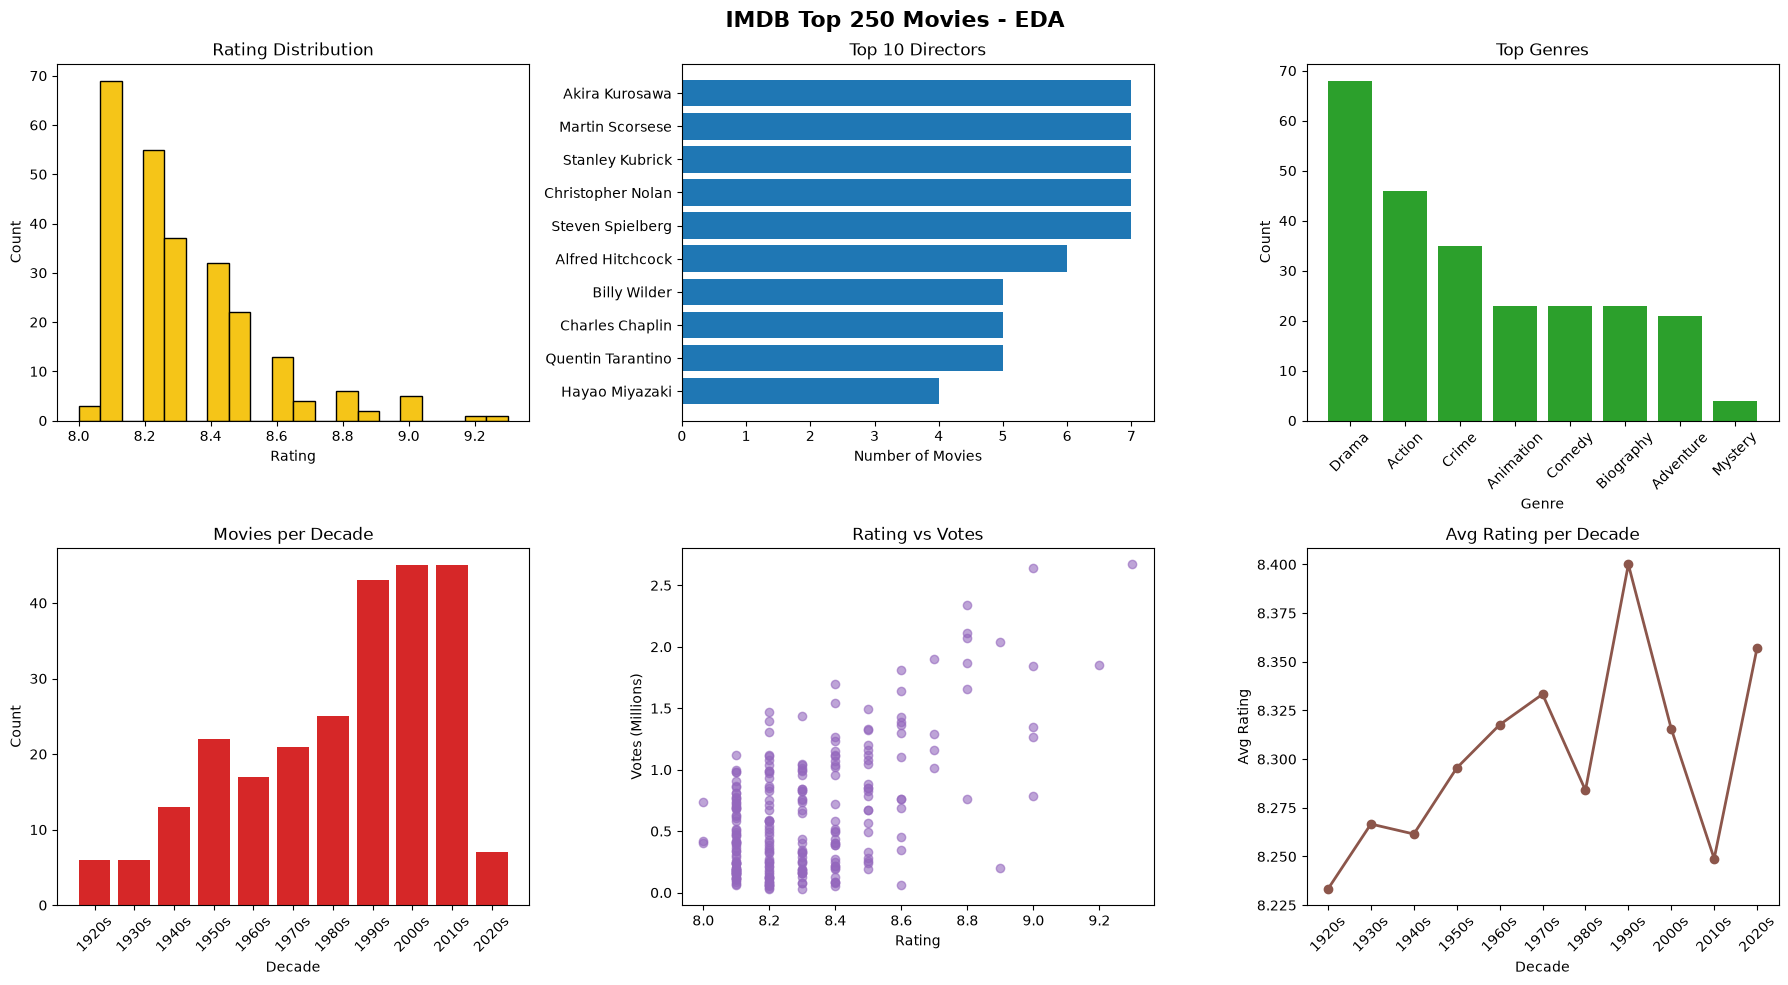

 Charts saved — eda_charts.png


In [6]:
# visualizations 
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("IMDB Top 250 Movies - EDA", fontsize=16, fontweight="bold")

# 1. Rating Distribution
axes[0,0].hist(df["Rating"], bins=20, color="#f5c518", edgecolor="black")
axes[0,0].set_title("Rating Distribution")
axes[0,0].set_xlabel("Rating")
axes[0,0].set_ylabel("Count")

# 2. Top 10 Directors
top_dirs = df["Director"].value_counts().head(10)
axes[0,1].barh(top_dirs.index, top_dirs.values, color="#1f77b4")
axes[0,1].set_title("Top 10 Directors")
axes[0,1].set_xlabel("Number of Movies")
axes[0,1].invert_yaxis()

# 3. Genre Distribution
top_genres = df["Primary_Genre"].value_counts().head(8)
axes[0,2].bar(top_genres.index, top_genres.values, color="#2ca02c")
axes[0,2].set_title("Top Genres")
axes[0,2].set_xlabel("Genre")
axes[0,2].set_ylabel("Count")
axes[0,2].tick_params(axis="x", rotation=45)

# 4. Movies per Decade
decade_counts = df["Decade"].value_counts().sort_index()
axes[1,0].bar(decade_counts.index, decade_counts.values, color="#d62728")
axes[1,0].set_title("Movies per Decade")
axes[1,0].set_xlabel("Decade")
axes[1,0].set_ylabel("Count")
axes[1,0].tick_params(axis="x", rotation=45)

# 5. Rating vs Votes
axes[1,1].scatter(df["Rating"], df["Votes_M"], alpha=0.6, color="#9467bd")
axes[1,1].set_title("Rating vs Votes")
axes[1,1].set_xlabel("Rating")
axes[1,1].set_ylabel("Votes (Millions)")

# 6. Avg Rating per Decade
avg_rating = df.groupby("Decade")["Rating"].mean()
axes[1,2].plot(avg_rating.index, avg_rating.values, 
               marker="o", color="#8c564b", linewidth=2)
axes[1,2].set_title("Avg Rating per Decade")
axes[1,2].set_xlabel("Decade")
axes[1,2].set_ylabel("Avg Rating")
axes[1,2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("eda_charts.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Charts saved — eda_charts.png")

In [7]:
# Final EDA Summary
print("=" * 55)
print(" EDA FINAL SUMMARY — IMDB Top 250 Movies")
print("=" * 55)

print("""
 DATASET:
   • 250 movies, 9 features, 0 missing values

 RATINGS:
   • Average rating: 8.31 (range: 8.0 to 9.3)
   • Most movies rated between 8.0 - 8.5
   • The Shawshank Redemption — highest rated (9.3)

 DIRECTORS:
   • Kurosawa, Scorsese, Kubrick, Nolan, Spielberg
     — each have 7 movies in Top 250
   • These 5 directors = 14% of entire list

 GENRES:
   • Drama is dominant — 68 movies (27%)
   • Action (46), Crime (35) follow
   • Animation surprisingly strong — 23 movies

 DECADES:
   • 2000s produced most Top 250 movies
   • Classic era (1950s-60s) still well represented

 POPULARITY:
   • Higher rating does NOT always mean more votes
   • Newer movies get more votes (more internet users)
   • Shawshank — most rated AND most voted
""")

print(" Task 2 — EDA Complete!")

 EDA FINAL SUMMARY — IMDB Top 250 Movies

 DATASET:
   • 250 movies, 9 features, 0 missing values

 RATINGS:
   • Average rating: 8.31 (range: 8.0 to 9.3)
   • Most movies rated between 8.0 - 8.5
   • The Shawshank Redemption — highest rated (9.3)

 DIRECTORS:
   • Kurosawa, Scorsese, Kubrick, Nolan, Spielberg
     — each have 7 movies in Top 250
   • These 5 directors = 14% of entire list

 GENRES:
   • Drama is dominant — 68 movies (27%)
   • Action (46), Crime (35) follow
   • Animation surprisingly strong — 23 movies

 DECADES:
   • 2000s produced most Top 250 movies
   • Classic era (1950s-60s) still well represented

 POPULARITY:
   • Higher rating does NOT always mean more votes
   • Newer movies get more votes (more internet users)
   • Shawshank — most rated AND most voted

 Task 2 — EDA Complete!
